In [1]:
import torch
from torch import nn
import numpy as np
import pandas as pd
import dataclasses
from dataclasses import dataclass, field
from typing import List
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
from template_modules import EncoderStaticBase, EncoderStaticBaseConfig
from collections.abc import Iterable
from basic_conv1d import bn_drop_lin
import warnings
warnings.filterwarnings('ignore')
from clinical_ts.template_modules import ShapeConfig
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

In [12]:


class BasicEncoderStatic(EncoderStaticBase):
    def __init__(self, hparams_encoder_static, hparams_input_shape, target_dim=None):
        super().__init__(hparams_encoder_static, hparams_input_shape, target_dim)
        self.input_channels_cat = hparams_input_shape.static_dim_cat
        self.input_channels_cont = hparams_input_shape.static_dim
        assert(len(hparams_encoder_static.embedding_dims)==hparams_input_shape.static_dim_cat and len(hparams_encoder_static.vocab_sizes)==hparams_input_shape.static_dim_cat)
        self.embeddings = nn.ModuleList() if hparams_input_shape.static_dim_cat is not None else None
        for v,e in zip(hparams_encoder_static.vocab_sizes,hparams_encoder_static.embedding_dims):
            self.embeddings.append(nn.Embedding(v,e))
        self.input_dim = int(np.sum(hparams_encoder_static.embedding_dims) + hparams_input_shape.static_dim)
        self.input_channels = hparams_input_shape.static_dim + hparams_input_shape.static_dim_cat


    def embed(self, **kwargs):
        static = kwargs["static"] if "static" in kwargs.keys() else None
        static_cat = kwargs["static_cat"] if "static_cat" in kwargs.keys() else None

        res = []
        if(static_cat is not None):
            for i,e in enumerate(self.embeddings):
                res.append(e(static_cat[:,i].long()))
            if(static is not None and static_cat is not None):
                res = torch.cat([torch.cat(res,dim=1),static],dim=1)
            else:
                res = torch.cat(res,dim=1)
        else:
            res = static

        return res

    def forward(self, **kwargs):
        raise NotImplementedError

    def get_output_shape(self):
        raise NotImplementedError

@dataclass
class BasicEncoderStaticConfig(EncoderStaticBaseConfig):
    _target_:str = "clinical_ts.tabular.base.BasicEncoderStatic"
    embedding_dims:List[int] = field(default_factory=lambda: []) #list with embedding dimensions
    vocab_sizes:List[int] = field(default_factory=lambda: []) #list with vocab sizes (space-separated)

class BasicEncoderStaticMLP(BasicEncoderStatic):
    def __init__(self, hparams_encoder_static, hparams_input_shape, target_dim=None):
        super().__init__(hparams_encoder_static, hparams_input_shape, target_dim)

        lin_ftrs = [self.input_dim] + list(hparams_encoder_static.lin_ftrs)
        if(target_dim is not None and lin_ftrs[-1]!=target_dim):
            lin_ftrs.append(target_dim)
        ps = [hparams_encoder_static.dropout] if not isinstance(hparams_encoder_static.dropout, Iterable) else hparams_encoder_static.dropout
        if len(ps)==1:
            ps= [ps[0]/2] * (len(lin_ftrs)-2) + ps
        actns = [nn.ReLU(inplace=True)] * (len(lin_ftrs)-2) + [None]
        layers = []
        for ni,no,p,actn in zip(lin_ftrs[:-1],lin_ftrs[1:],ps,actns):
            layers+=bn_drop_lin(ni,no,hparams_encoder_static.batch_norm,p,actn,layer_norm=False)
        self.layers=nn.Sequential(*layers)

        self.output_shape = dataclasses.replace(hparams_input_shape)
        self.output_shape.static_dim = int(lin_ftrs[-1])
        self.output_shape.static_dim_cat = 0

    def forward(self, **kwargs):
        res = self.embed(**kwargs)
        return {"static": self.layers(res)}

    def get_output_shape(self):
        return self.output_shape


@dataclass
class BasicEncoderStaticMLPConfig(BasicEncoderStaticConfig):
    _target_:str = "clinical_ts.tabular.base.BasicEncoderStaticMLP"
    lin_ftrs:List[int] = field(default_factory=lambda: [512]) #list with MLP hidden layer sizes; last entry is the static encoder output dimension in case target_dim is not specified
    dropout:float = 0.5
    batch_norm:bool = True

In [2]:
# ----------------------------------------
# Config (matches YAML)
# ----------------------------------------
BATCH_SIZE = 32
EPOCHS     = 10
LR         = 0.001
WEIGHT_DECAY = 0.001
DROPOUT    = 0.5
LIN_FTRS   = [128, 128, 128]

In [3]:
# ----------------------------------------
# 1. Load data (same as multimodal.py)
# ----------------------------------------
print("Loading data...")
df = pd.read_csv(r'C:\Users\Taki Djebbar\Documents\Data Science S1\Medical Data Analysis with Deep Learning\Other\mds_ed.csv',
                 low_memory=False)
print(f"shape: {df.shape}")

Loading data...
shape: (129057, 1936)


In [4]:
input_cols = [c for c in df.columns if c.split("_")[0] in ['biometrics','demographics','labvalues','vitals']]

# median imputation based on training set
df_train = df[df['general_strat_fold'] < 18]
train_medians = df_train[input_cols].median().to_dict()
train_nans = [c for c,v in df_train[input_cols].isna().sum().to_dict().items() if v > 0]
for c in train_nans:
    df.loc[df[c].isna(), c] = train_medians[c]
df = df.copy()

In [5]:
# categorical vs continuous feature split (same as multimodal.py)
unique_counts = {c: len(np.unique(np.array(df[c]))) for c in input_cols}
cat_features = [c for c,v in unique_counts.items() if v < 10 and not c.endswith("nan") and not c.startswith("labvalues")]
cat_features_dim = [unique_counts[c] for c in cat_features]
cont_features = [c for c in input_cols if c not in cat_features]

print(f"categorical features: {len(cat_features)} dimensions: {cat_features_dim} continuous features: {len(cont_features)}")

categorical features: 7 dimensions: [2, 2, 2, 2, 2, 2, 5] continuous features: 463


In [6]:
# vitals_acuity: convert from 1-based to 0-based indexing
df["vitals_acuity"] = df["vitals_acuity"].apply(lambda x: int(x)-1)

# ethnicity → categorical encoding (same as multimodal.py)
lbl_itos_ethnicity = [
    'demographics_ethnicity_asian',
    'demographics_ethnicity_black/african',
    'demographics_ethnicity_hispanic/latino',
    'demographics_ethnicity_other',
    'demographics_ethnicity_white'
]

df["demographics_ethnicity"] = df.apply(
    lambda row: np.where([row[c] for c in lbl_itos_ethnicity])[0][0], axis=1
)
df.drop(lbl_itos_ethnicity, axis=1, inplace=True)

In [7]:
input_cols = [c for c in df.columns if c.split("_")[0] in ['biometrics','demographics','labvalues','vitals']]
cat_features = [c for c in cat_features if c in df.columns]
cat_features = [c for c in input_cols if c in cat_features]
cont_features = [c for c in input_cols if c not in cat_features]

# deterioration labels
lbl_itos_deterioration = ["mortality_1d","icu_24h","cardiac_arrest","vasopressors"]
for c in lbl_itos_deterioration:
    df["deterioration_"+c] = df["deterioration_"+c].replace(-999., np.nan)

In [8]:
target_cols = [
    "deterioration_mortality_1d",
    "deterioration_icu_24h",
    "deterioration_icu_24h",
    "deterioration_vasopressors"
]

In [9]:
# 3. Train / Validation / Test split
# ----------------------------------------
train_df = df[df['general_strat_fold'].isin(range(0, 18))].reset_index(drop=True)
val_df   = df[df['general_strat_fold'] == 18].reset_index(drop=True)
test_df  = df[df['general_strat_fold'] == 19].reset_index(drop=True)
# only first ECG per hospital stay for validation/test
val_df   = val_df[val_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)
test_df  = test_df[test_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)

print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

Train: 116433, Validation: 5824, Test: 6080


In [10]:
# 4. Dataset
# ----------------------------------------
class TabularDataset(Dataset):
    def __init__(self, df, cont_features, cat_features, lbl_cols):
        self.cont = torch.tensor(df[cont_features].values, dtype=torch.float32)
        self.cat  = torch.tensor(df[cat_features].values, dtype=torch.long)
        self.labels = torch.tensor(df[["deterioration_"+c for c in lbl_cols]].values, dtype=torch.float32)

    def __len__(self):
        return len(self.cont)

    def __getitem__(self, idx):
        return self.cont[idx], self.cat[idx], self.labels[idx]

train_ds = TabularDataset(train_df, cont_features, cat_features, lbl_itos_deterioration)
val_ds   = TabularDataset(val_df,   cont_features, cat_features, lbl_itos_deterioration)
test_ds  = TabularDataset(test_df,  cont_features, cat_features, lbl_itos_deterioration)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [13]:
# 5. Model initialization (BasicEncoderStaticMLP unchanged)
# ----------------------------------------
@dataclass
class MLPConfig:
    embedding_dims: List[int] = field(default_factory=lambda: [16, 16, 16])
    vocab_sizes: List[int]    = field(default_factory=lambda: [2, 5, 5])
    lin_ftrs: List[int]       = field(default_factory=lambda: [128, 128, 128])
    dropout: float = 0.5
    batch_norm: bool = True

@dataclass
class ShapeCfg:
    static_dim: int = 0
    static_dim_cat: int = 0
    channels: int = 0
    length: int = 0
    sequence_last: bool = False
    channels2: int = 0

shape = ShapeCfg(static_dim=len(cont_features), static_dim_cat=len(cat_features))

mlp_cfg = MLPConfig(
    embedding_dims=[unique_counts[c] for c in cat_features],
    vocab_sizes=[unique_counts[c] for c in cat_features],
    lin_ftrs=LIN_FTRS
)

encoder = BasicEncoderStaticMLP(mlp_cfg, shape, target_dim=len(lbl_itos_deterioration))
print(f"\nModel parameter count: {sum(p.numel() for p in encoder.parameters()):,}")


Model parameter count: 95,695


In [14]:
# 6. Loss and optimizer
# ----------------------------------------
def bce_loss_with_nans(preds, targets):
    mask = ~torch.isnan(targets)
    if mask.sum() == 0:
        return torch.tensor(0.0, requires_grad=True)
    return nn.BCEWithLogitsLoss()(preds[mask], targets[mask])

optimizer = torch.optim.AdamW(encoder.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

In [15]:
# 7. Training loop
# ----------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}\n")
encoder = encoder.to(device)

best_val_auroc = 0
best_epoch = 0

for epoch in range(EPOCHS):

    # Training
    encoder.train()
    train_loss = 0
    for cont, cat, labels in train_loader:
        cont, cat, labels = cont.to(device), cat.to(device), labels.to(device)
        optimizer.zero_grad()
        out = encoder(static=cont, static_cat=cat)
        logits = out["static"]
        loss = bce_loss_with_nans(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation AUROC
    encoder.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for cont, cat, labels in val_loader:
            cont, cat = cont.to(device), cat.to(device)
            out = encoder(static=cont, static_cat=cat)
            logits = torch.sigmoid(out["static"])
            all_preds.append(logits.cpu().numpy())
            all_labels.append(labels.numpy())

    all_preds  = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    aurocs = []
    for i in range(len(lbl_itos_deterioration)):
        mask = ~np.isnan(all_labels[:, i])
        if mask.sum() > 0 and len(np.unique(all_labels[mask, i])) > 1:
            aurocs.append(roc_auc_score(all_labels[mask, i], all_preds[mask, i]))

    val_auroc = np.mean(aurocs) if aurocs else 0
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | loss: {train_loss/len(train_loader):.4f} | val macro AUROC: {val_auroc:.4f}")

    if val_auroc > best_val_auroc:
        best_val_auroc = val_auroc
        best_epoch = epoch + 1
        torch.save(encoder.state_dict(), 'best_realmlp.pt')

print(f"\nBest validation AUROC: {best_val_auroc:.4f} at epoch {best_epoch}")


Device: cpu

Epoch 01/10 | loss: 0.1234 | val macro AUROC: 0.9142
Epoch 02/10 | loss: 0.0895 | val macro AUROC: 0.9099
Epoch 03/10 | loss: 0.0879 | val macro AUROC: 0.9159
Epoch 04/10 | loss: 0.0871 | val macro AUROC: 0.9148
Epoch 05/10 | loss: 0.0858 | val macro AUROC: 0.9167
Epoch 06/10 | loss: 0.0848 | val macro AUROC: 0.9151
Epoch 07/10 | loss: 0.0840 | val macro AUROC: 0.9127
Epoch 08/10 | loss: 0.0835 | val macro AUROC: 0.9162
Epoch 09/10 | loss: 0.0827 | val macro AUROC: 0.9191
Epoch 10/10 | loss: 0.0828 | val macro AUROC: 0.9227

Best validation AUROC: 0.9227 at epoch 10


In [16]:
target_idx = lbl_itos_deterioration.index("icu_24h")

mask = ~np.isnan(all_labels[:, target_idx])

y_true = all_labels[mask, target_idx]
y_prob = all_preds[mask, target_idx]

# ICE_24H prediction at a 0.1 threshold 

In [17]:

target_idx = lbl_itos_deterioration.index("icu_24h")

# ----------------------------------------
# 1. predictions
# ----------------------------------------
all_probs = []
all_labels = []

with torch.no_grad():
    for cont, cat, labels in test_loader:

        cont = cont.to(device)
        cat = cat.to(device)

        out = encoder(static=cont, static_cat=cat)
        probs = torch.sigmoid(out["static"])

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

In [18]:

# ----------------------------------------
# 2. time column
# ----------------------------------------
time = test_df["general_icu_time_hours"].values

# ----------------------------------------
# 3. filter icu_24h valid rows
# ----------------------------------------
mask = ~np.isnan(all_labels[:, target_idx])

y_prob = all_probs[mask, target_idx]
y_time = time[mask]

# ----------------------------------------
# 4. create dataframe for aggregation
# ----------------------------------------
df_plot = pd.DataFrame({
    "time": y_time,
    "prob": y_prob
})


In [19]:


# ----------------------------------------
# 5. mean probability per time
# ----------------------------------------
df_mean = df_plot.groupby("time", as_index=False).mean()

# sort just in case
df_mean = df_mean.sort_values("time")

# ----------------------------------------
# 6. smooth curve (optional but recommended)
# ----------------------------------------
from scipy.ndimage import gaussian_filter1d

smooth_prob = gaussian_filter1d(df_mean["prob"].values, sigma=2)


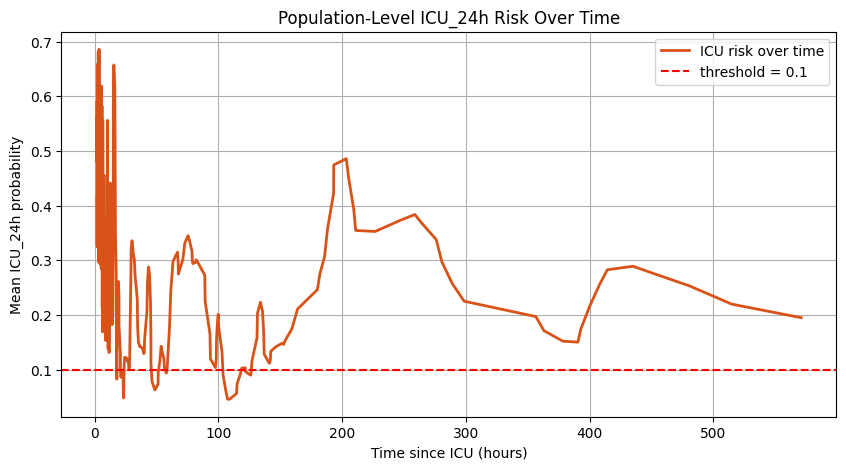

In [20]:

# ----------------------------------------
# 7. plot
# ----------------------------------------
plt.figure(figsize=(10,5))

plt.plot(df_mean["time"], smooth_prob, linewidth=2,   color=(0.8500, 0.3250, 0.0980), label="ICU risk over time")

plt.axhline(0.1, color="red", linestyle="--", label="threshold = 0.1")

plt.xlabel("Time since ICU (hours)")
plt.ylabel("Mean ICU_24h probability")
plt.title("Population-Level ICU_24h Risk Over Time")

plt.legend()
plt.grid()
plt.show()

In [37]:
[c for c in test_df.columns if "time" in c.lower() or "hour" in c.lower() or "ecg" in c.lower()]

['general_ecg_time',
 'general_ecg_no_within_stay',
 'general_intime',
 'general_outtime',
 'general_mortality_hours',
 'general_hosp_dischtime',
 'general_icu_time_hours']

# Class predictions at different thresholds using the BasicEncoderStaticMLP

In [21]:

def evaluate_thresholds(y_true, y_prob, thresholds=np.arange(0.01, 0.5, 0.01), cFP=1,
    cFN=1):
    
    results = []

    for thr in thresholds:

        y_pred = (y_prob >= thr).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        sensitivity = tp / (tp + fn )   # recall
        specificity = tn / (tn + fp )

        precision = tp / (tp + fp)
        # Cost function
        cost = cFP * fp + cFN * fn

        results.append({
            "threshold": thr,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "precision": precision,
            "False Positive": fp,
            "tp": tp,
            "False Negative": fn,
            "tn": tn,
            "cost": cost
        })

    return pd.DataFrame(results)

In [22]:
encoder.load_state_dict(torch.load("best_realmlp.pt"))
encoder.eval()

BasicEncoderStaticMLP(
  (embeddings): ModuleList(
    (0): Embedding(2, 2)
    (1): Embedding(5, 5)
  )
  (layers): Sequential(
    (0): BatchNorm1d(471, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Dropout(p=0.25, inplace=False)
    (2): Linear(in_features=471, out_features=128, bias=True)
    (3): ReLU(inplace=True)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): Dropout(p=0.25, inplace=False)
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU(inplace=True)
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Dropout(p=0.25, inplace=False)
    (10): Linear(in_features=128, out_features=128, bias=True)
    (11): ReLU(inplace=True)
    (12): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): Dropout(p=0.5, inplace=False)
    (14): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [23]:
all_preds, all_labels = [], []

with torch.no_grad():

    for cont, cat, labels in val_loader:

        cont = cont.to(device)
        cat  = cat.to(device)

        out = encoder(static=cont, static_cat=cat)

        probs = torch.sigmoid(out["static"])

        all_preds.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds  = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

In [24]:
all_results = []


mask = ~np.isnan(all_labels[:, 1])

y_true = all_labels[mask, i]
y_prob = all_preds[mask, i]

df_thr = evaluate_thresholds(y_true, y_prob, cFP=1, cFN=1)

print("\n")
print("="*60)
print('icu_24h')
print("="*60)

print(df_thr[[
    "threshold",
    "sensitivity",
    "specificity",
    "precision",
    "False Positive",
    "False Negative"
]])
df_thr["label"] = 'icu_24h'

all_results.append(df_thr)

results_df = pd.concat(all_results, ignore_index=True)



icu_24h
    threshold  sensitivity  specificity  precision  False Positive  \
0        0.01     0.723404     0.898090   0.054750             587   
1        0.02     0.617021     0.934722   0.071605             376   
2        0.03     0.553191     0.953819   0.089041             266   
3        0.04     0.510638     0.962153   0.099174             218   
4        0.05     0.489362     0.968576   0.112745             181   
5        0.06     0.489362     0.972917   0.128492             156   
6        0.07     0.446809     0.978125   0.142857             126   
7        0.08     0.404255     0.980903   0.147287             110   
8        0.09     0.361702     0.982465   0.144068             101   
9        0.10     0.276596     0.984375   0.126214              90   
10       0.11     0.276596     0.984722   0.128713              88   
11       0.12     0.276596     0.985764   0.136842              82   
12       0.13     0.255319     0.986285   0.131868              79   
13       0

In [25]:
# Filtering the confusion matrix's result to 'icu_24h'
icu_24h_results=results_df[results_df['label']=='icu_24h']
icu_24h_results.columns=['Threshold', 'Sensitivity', 'Specificity', 'Precision',
       'False Positive', 'True Positive', 'False Negative', 'True Negative', 'Cost Function', 'label']
icu_24h_results.drop(columns='label')

,Threshold,Sensitivity,Specificity,Precision,False Positive,True Positive,False Negative,True Negative,Cost Function
0,0.01,0.723404,0.898090,0.054750,587,34,13,5173,600
1,0.02,0.617021,0.934722,0.071605,376,29,18,5384,394
2,0.03,0.553191,0.953819,0.089041,266,26,21,5494,287
3,0.04,0.510638,0.962153,0.099174,218,24,23,5542,241
4,0.05,0.489362,0.968576,0.112745,181,23,24,5579,205
5,0.06,0.489362,0.972917,0.128492,156,23,24,5604,180
6,0.07,0.446809,0.978125,0.142857,126,21,26,5634,152
7,0.08,0.404255,0.980903,0.147287,110,19,28,5650,138
8,0.09,0.361702,0.982465,0.144068,101,17,30,5659,131
9,0.10,0.276596,0.984375,0.126214,90,13,34,5670,124


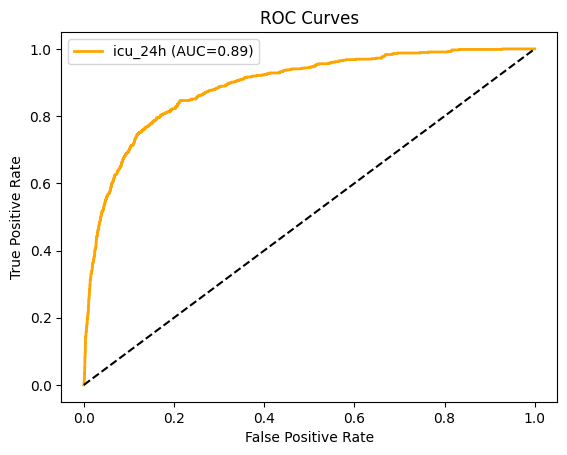

In [26]:
plt.figure()

mask = ~np.isnan(all_labels[:, 1])

y_true = all_labels[mask, 1]
y_prob = all_preds[mask, 1]

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(
    fpr,
    tpr,
    color="orange",         
    linewidth=2,
    label=f"{'icu_24h'} (AUC={roc_auc:.2f})"
)

plt.plot([0, 1], [0, 1], "--", color="black")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()

plt.show()

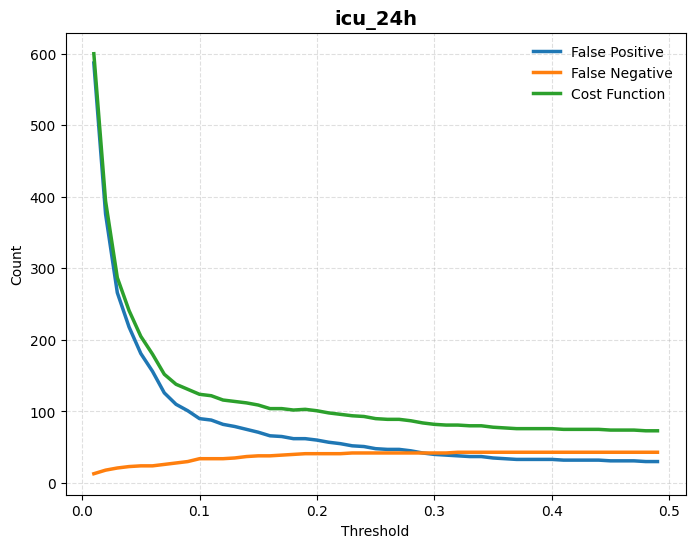

In [27]:
df = results_df[results_df["label"] == "icu_24h"]

x = df["threshold"]
fp = df["False Positive"]
fn = df["False Negative"]
cost_fct = df["cost"]

best_row = df.loc[df["cost"].idxmin()]

plt.figure(figsize=(8, 6))

plt.plot(x, fp, label="False Positive", linewidth=2.5)
plt.plot(x, fn, label="False Negative", linewidth=2.5)
plt.plot(x, cost_fct, label="Cost Function", linewidth=2.5)

plt.title("icu_24h", fontsize=14, fontweight="bold")
plt.xlabel("Threshold")
plt.ylabel("Count")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(frameon=False)

plt.show()

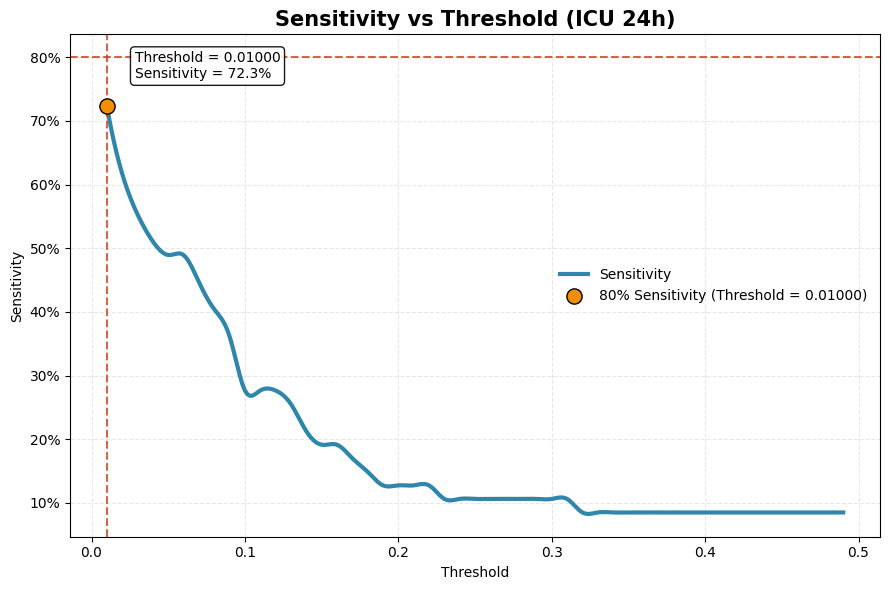

In [28]:
from scipy.interpolate import make_interp_spline

# Filter and sort data
df_plot = df.sort_values("threshold")

x = df_plot["threshold"].values
y = df_plot["sensitivity"].values

# Smooth curve
x_smooth = np.linspace(x.min(), x.max(), 300)
spline = make_interp_spline(x, y, k=3)
y_smooth = spline(x_smooth)

# Find threshold corresponding to 80% sensitivity
target_sens = 0.80

idx = np.argmin(np.abs(y_smooth - target_sens))
thr = x_smooth[idx]
sens = y_smooth[idx]

plt.figure(figsize=(9, 6))

# Sensitivity curve
plt.plot(
    x_smooth,
    y_smooth,
    color="#2E86AB",
    linewidth=3,
    label="Sensitivity"
)

# Mark 80% sensitivity point
plt.scatter(
    thr,
    sens,
    color="#F18F01",
    s=120,
    edgecolor="black",
    zorder=5,
    label=f"80% Sensitivity (Threshold = {thr:.5f})"
)

# Reference lines
plt.axvline(
    thr,
    color="#C73E1D",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

plt.axhline(
    target_sens,
    color="#C73E1D",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

# Annotation
plt.annotate(
    f"Threshold = {thr:.5f}\nSensitivity = {sens:.1%}",
    (thr, sens),
    xytext=(20, 20),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9)
)

# Titles and labels
plt.title(
    "Sensitivity vs Threshold (ICU 24h)",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Threshold")
plt.ylabel("Sensitivity")

# Optional: show y-axis as percentages
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

In [25]:
encoder.load_state_dict(torch.load('best_realmlp.pt'))
encoder.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for cont, cat, labels in test_loader:
        cont, cat = cont.to(device), cat.to(device)
        out = encoder(static=cont, static_cat=cat)
        logits = torch.sigmoid(out["static"])
        all_preds.append(logits.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds  = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

results = []
for i, col in enumerate(lbl_itos_deterioration):
    mask = ~np.isnan(all_labels[:, i])
    if mask.sum() > 0 and len(np.unique(all_labels[mask, i])) > 1:
        auroc = roc_auc_score(all_labels[mask, i], all_preds[mask, i])
        results.append({'target': col, 'auroc': auroc, 'n': mask.sum()})
        print(f"{col}: AUROC={auroc:.4f} (n={mask.sum()})")

results_df = pd.DataFrame(results)
print(f"\nMacro average AUROC: {results_df['auroc'].mean():.4f}")
results_df.to_csv('realmlp_results.csv', index=False)
print("Saved results: realmlp_results.csv")

mortality_1d: AUROC=0.9291 (n=6069)
icu_24h: AUROC=0.8835 (n=6051)
cardiac_arrest: AUROC=0.9445 (n=6080)
vasopressors: AUROC=0.8920 (n=6080)

Macro average AUROC: 0.9123
Saved results: realmlp_results.csv


In [29]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

In [30]:
def mc_dropout_predict(model, test_loader, device, n_samples=50):

    model.train()  # IMPORTANT: keep dropout active

    all_mean_preds = []
    all_uncertainties = []
    all_labels = []

    with torch.no_grad():

        for cont, cat, labels in test_loader:

            cont = cont.to(device)
            cat  = cat.to(device)

            mc_samples = []

            # ----------------------------------------
            # Multiple stochastic forward passes
            # ----------------------------------------
            for _ in range(n_samples):

                out = model(static=cont, static_cat=cat)
                probs = torch.sigmoid(out["static"])

                mc_samples.append(probs.cpu().numpy())

            mc_samples = np.array(mc_samples)

            # ----------------------------------------
            # MC statistics
            # ----------------------------------------
            mean_preds = mc_samples.mean(axis=0)
            uncertainty = mc_samples.std(axis=0)

            all_mean_preds.append(mean_preds)
            all_uncertainties.append(uncertainty)
            all_labels.append(labels.numpy())

    all_mean_preds = np.concatenate(all_mean_preds, axis=0)
    all_uncertainties = np.concatenate(all_uncertainties, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_mean_preds, all_uncertainties, all_labels

In [31]:
print("\nRunning Monte Carlo Dropout...")

all_mean_preds, all_uncertainties, y_true = mc_dropout_predict(
    encoder,
    test_loader,
    device,
    n_samples=50
)


Running Monte Carlo Dropout...


# Alarm system using MC dropout

In [38]:
# ----------------------------------------
# 1. MC dropout predictions
# ----------------------------------------
all_probs, all_uncertainties, all_labels = mc_dropout_predict(
    encoder, test_loader, device, n_samples=50
)

In [40]:
# ----------------------------------------
# 2. time column
# ----------------------------------------
time = test_df["general_icu_time_hours"].values

# ----------------------------------------
# 3. filter icu_24h valid rows
# ----------------------------------------
mask = ~np.isnan(all_labels[:, target_idx])

y_prob        = all_probs[mask, target_idx]
y_uncertainty = all_uncertainties[mask, target_idx]
y_time        = time[mask]

# ----------------------------------------
# 4. create dataframe for aggregation
# ----------------------------------------
df_plot = pd.DataFrame({
    "time":        y_time,
    "prob":        y_prob,
    "uncertainty": y_uncertainty
})

In [41]:
# ----------------------------------------
# 5. mean probability + uncertainty per time
# ----------------------------------------
df_mean = df_plot.groupby("time", as_index=False).agg(
    prob        = ("prob",        "mean"),
    uncertainty = ("uncertainty", "mean")
)

df_mean = df_mean.sort_values("time")

# ----------------------------------------
# 6. smooth curves
# ----------------------------------------
from scipy.ndimage import gaussian_filter1d

smooth_prob        = gaussian_filter1d(df_mean["prob"].values,        sigma=2)
smooth_uncertainty = gaussian_filter1d(df_mean["uncertainty"].values, sigma=2)

# Find the FP, FN, TP, TN, sensitivity, specificity at default threshold (0.1238)

In [32]:

results_confusion = []



y_test = y_true[:, 1]
pred_prob = all_mean_preds[:, 1]

mask = ~np.isnan(y_test)

y_test = y_test[mask]
pred_prob = pred_prob[mask]


y_class = (pred_prob >= 0.1238).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_class).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

results_confusion.append({
    "target": 'icu_24h',
    "TP": tp,
    "FP": fp,
    "TN": tn,
    "FN": fn,
    "sensitivity": sensitivity,
    "specificity": specificity,
    "n_samples": len(y_test)
})

confusion_df = pd.DataFrame(results_confusion)
print(confusion_df)

    target   TP    FP    TN   FN  sensitivity  specificity  n_samples
0  icu_24h  601  1120  4201  129     0.823288     0.789513       6051


# TP, FP, TN, FN at uncertainty = 0.1 

In [33]:
threshold = 0.1238

# ----------------------------
# ICU_24h ONLY
# ----------------------------
y_test = y_true[:, 1]
pred_prob = all_mean_preds[:, 1]
uncertainty = all_uncertainties[:, 1]

uncertainty_thresholds = [0.05,0.1, 0.25]

results = []

for u_cut in uncertainty_thresholds:

    for group_name, mask_unc in [
        (f"≤ {u_cut}", uncertainty <= u_cut),
        (f"> {u_cut}", uncertainty > u_cut),
    ]:

        mask = mask_unc & (~np.isnan(y_test))

        y_t = y_test[mask]
        y_p = pred_prob[mask]

        y_pred = (y_p >= threshold).astype(int)

        if len(y_t) == 0:
            results.append({
                "uncertainty_cutoff": u_cut,
                "group": group_name,
                "TP": 0, "FP": 0, "TN": 0, "FN": 0,
                "sensitivity": np.nan,
                "specificity": np.nan,
                "n_samples": 0
            })
            continue

        tn, fp, fn, tp = confusion_matrix(y_t, y_pred).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

        results.append({
            "uncertainty_cutoff": u_cut,
            "group": group_name,
            "TP": tp,
            "FP": fp,
            "TN": tn,
            "FN": fn,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "n_samples": len(y_t)
        })

df = pd.DataFrame(results)
print(df)

   uncertainty_cutoff   group   TP    FP    TN   FN  sensitivity  specificity  \
0                0.05  ≤ 0.05    9    68  3996  111     0.075000     0.983268   
1                0.05  > 0.05  592  1052   205   18     0.970492     0.163087   
2                0.10   ≤ 0.1  340   759  4201  129     0.724947     0.846976   
3                0.10   > 0.1  261   361     0    0     1.000000     0.000000   
4                0.25  ≤ 0.25  601  1120  4201  129     0.823288     0.789513   
5                0.25  > 0.25    0     0     0    0          NaN          NaN   

   n_samples  
0       4184  
1       1867  
2       5429  
3        622  
4       6051  
5          0  


In [34]:
results = []

for target_idx, target_name in enumerate(lbl_itos_deterioration):

    y_test = y_true[:, target_idx]
    y_pred = all_mean_preds[:, target_idx]
    uncertainty = all_uncertainties[:, target_idx]

    mask = ~np.isnan(y_test)

    y_test = y_test[mask]
    y_pred = y_pred[mask]
    uncertainty = uncertainty[mask]

    if len(np.unique(y_test)) < 2:
        continue

    auroc = roc_auc_score(y_test, y_pred)
    auprc = average_precision_score(y_test, y_pred)
    brier = brier_score_loss(y_test, y_pred)

    results.append({
        "target": target_name,
        "auroc": auroc,
        "auprc": auprc,
        "brier_score": brier,
        "mean_uncertainty": uncertainty.mean(),
        "test_n": len(y_test),
        "positive_rate": y_test.mean()
    })

results_df = pd.DataFrame(results)

results_df.to_csv("realmlp_mc_dropout_results.csv", index=False)

print("\n===== FINAL RESULTS =====")
print(results_df.to_string(index=False))


===== FINAL RESULTS =====
        target    auroc    auprc  brier_score  mean_uncertainty  test_n  positive_rate
  mortality_1d 0.941238 0.218056     0.005877          0.004547    6069       0.006591
       icu_24h 0.891803 0.621106     0.068535          0.042140    6051       0.120641
cardiac_arrest 0.964788 0.429100     0.003663          0.003812    6080       0.004934
  vasopressors 0.884903 0.102574     0.008328          0.005242    6080       0.008882


# calculate 75th, 90th, and 95th certain and uncertain FP, TP, FN, TN

In [ ]:
y_test = y_true[:, 1]
pred_prob = all_mean_preds[:, 1]
uncertainty = all_uncertainties[:, 1]

# Percentile thresholds
u_75 = np.percentile(uncertainty[~np.isnan(uncertainty)], 75)
u_90 = np.percentile(uncertainty[~np.isnan(uncertainty)], 90)
u_95 = np.percentile(uncertainty[~np.isnan(uncertainty)], 95)

results = []

for name, mask in [
    ("≤ 75th percentile (certain)", uncertainty <= u_75),
    ("> 75th percentile (uncertain)", uncertainty > u_75),

    ("≤ 90th percentile (certain)", uncertainty <= u_90),
    ("> 90th percentile (uncertain)", uncertainty > u_90),

    ("≤ 95th percentile (certain)", uncertainty <= u_95),
    ("> 95th percentile (uncertain)", uncertainty > u_95),
]:

    m = mask & (~np.isnan(y_test))

    y_t = y_test[m]
    y_p = pred_prob[m]

    y_pred = (y_p >= 0.1238).astype(int)

    if len(y_t) == 0:
        continue

    tn, fp, fn, tp = confusion_matrix(y_t, y_pred).ravel()

    results.append({
        "group": name,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "n_samples": len(y_t),
        "sensitivity": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
    })

results_df = pd.DataFrame(results)
print(results_df)

                           group   TP   FP    TN   FN  n_samples  sensitivity  \
0    ≤ 75th percentile (certain)   46  257  4133  121       4557     0.275449   
1  > 75th percentile (uncertain)  555  863    68    8       1494     0.985790   
2    ≤ 90th percentile (certain)  349  781  4198  129       5457     0.730126   
3  > 90th percentile (uncertain)  252  339     3    0        594     1.000000   
4    ≤ 95th percentile (certain)  475  952  4199  129       5755     0.786424   
5  > 95th percentile (uncertain)  126  168     2    0        296     1.000000   

   specificity  
0     0.941458  
1     0.073040  
2     0.843141  
3     0.008772  
4     0.815182  
5     0.011765  


In [53]:
# ----------------------------------------
# align lengths upfront
# ----------------------------------------
min_len = min(len(y_test), len(pred_prob), len(uncertainty))

y_test_v      = y_test[:min_len]
pred_prob_v   = pred_prob[:min_len]
uncertainty_v = uncertainty[:min_len]

valid_mask    = ~np.isnan(y_test_v)

y_test_v      = y_test_v[valid_mask]
pred_prob_v   = pred_prob_v[valid_mask]
uncertainty_v = uncertainty_v[valid_mask]

# ----------------------------------------
# percentile thresholds
# ----------------------------------------
u_75 = np.percentile(uncertainty_v, 75)
u_90 = np.percentile(uncertainty_v, 90)
u_95 = np.percentile(uncertainty_v, 95)

results = []

for name, mask in [
    ("≤ 75th percentile (certain)", uncertainty_v <= u_75),
    ("> 75th percentile",                uncertainty_v >  u_75),

    ("≤ 90th percentile (certain)", uncertainty_v <= u_90),
    ("> 90th percentile",                uncertainty_v >  u_90),

    ("≤ 95th percentile (certain)", uncertainty_v <= u_95),
    ("> 95th percentile (uncertain)", uncertainty_v > u_95),
]:
    y_t = y_test_v[mask]
    y_p = pred_prob_v[mask]

    y_pred = (y_p >= 0.1238).astype(int)

    if len(y_t) == 0:
        continue

    tn, fp, fn, tp = confusion_matrix(y_t, y_pred).ravel()

    n          = len(y_t)
    n_pos      = tp + fn
    n_neg      = tn + fp
    n_pred_pos = tp + fp

    results.append({
        "group"                   : name,
        "n"                       : n,
        "prevalence% (pos/n)"     : round(100 * n_pos / n, 1),
        "sensitivity% (TP/pos)"   : round(100 * tp / n_pos, 1)      if n_pos      > 0 else np.nan,
        "precision% (TP/(TP+FP))" : round(100 * tp / n_pred_pos, 1) if n_pred_pos > 0 else np.nan,
        "FDR% (FP/(TP+FP))"       : round(100 * fp / n_pred_pos, 1) if n_pred_pos > 0 else np.nan,
        "FN/(FN+TN)%"             : round(100 * fn / (fn + tn), 1)  if (fn + tn)  > 0 else np.nan,
        "fall-out% (FP/neg)"      : round(100 * fp / n_neg, 1)       if n_neg      > 0 else np.nan,
        "specificity% (TN/neg)"   : round(100 * tn / n_neg, 1)       if n_neg      > 0 else np.nan,
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                        group    n  prevalence% (pos/n)  sensitivity% (TP/pos)  precision% (TP/(TP+FP))  FDR% (FP/(TP+FP))  FN/(FN+TN)%  fall-out% (FP/neg)  specificity% (TN/neg)
  ≤ 75th percentile (certain) 4538                  3.6                   26.7                     15.3               84.7          2.8                 5.6                   94.4
            > 75th percentile 1513                 37.3                   98.6                     38.8               61.2         10.1                92.5                    7.5
  ≤ 90th percentile (certain) 5446                  8.7                   72.8                     30.9               69.1          3.0                15.6                   84.4
            > 90th percentile  605                 42.1                  100.0                     42.4               57.6          0.0                99.1                    0.9
  ≤ 95th percentile (certain) 5748                 10.5                   78.5                     33.2  

# Expected Calibration Error 

In [37]:
def expected_calibration_error(y_true, y_prob, n_bins=10):

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bins = np.linspace(0.0, 1.0, n_bins + 1)

    ece = 0.0
    n = len(y_true)

    for i in range(n_bins):

        bin_lower = bins[i]
        bin_upper = bins[i + 1]

        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)

        if np.sum(mask) == 0:
            continue

        bin_acc = np.mean(y_true[mask])
        bin_conf = np.mean(y_prob[mask])

        weight = np.sum(mask) / n

        ece += weight * abs(bin_acc - bin_conf)

    return ece


# ============================
# ICU_24h ECE computation
# ============================

# extract ICU_24h only
y_test = y_true[:, 1]
y_prob = all_mean_preds[:, 1]

# remove NaNs
mask = ~np.isnan(y_test)

y_test = y_test[mask]
y_prob = y_prob[mask]

# ensure numpy arrays
y_test = np.asarray(y_test)
y_prob = np.asarray(y_prob)

# compute ECE
ece = expected_calibration_error(y_test, y_prob, n_bins=10)

print("ECE (ICU_24h):", ece)

ECE (ICU_24h): 0.019206793417646518


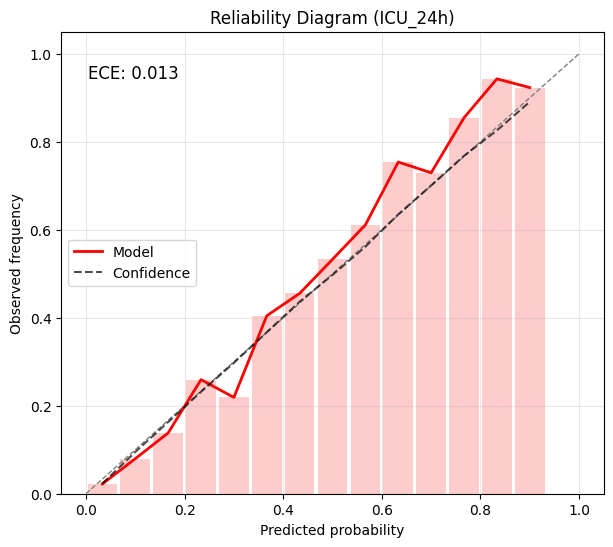

ECE: 0.013349369541364668


In [ ]:
def expected_calibration_error_and_bins(y_true, y_prob, n_bins=15):

    bins = np.linspace(0, 1, n_bins + 1)

    bin_acc = []
    bin_conf = []
    bin_sizes = []

    ece = 0.0
    n = len(y_true)

    for i in range(n_bins):

        left, right = bins[i], bins[i + 1]

        if i == n_bins - 1:
            mask = (y_prob >= left) & (y_prob <= right)
        else:
            mask = (y_prob >= left) & (y_prob < right)

        if np.sum(mask) == 0:
            bin_acc.append(np.nan)
            bin_conf.append(np.nan)
            bin_sizes.append(0)
            continue

        acc = np.mean(y_true[mask])
        conf = np.mean(y_prob[mask])

        weight = np.sum(mask) / n
        ece += weight * abs(acc - conf)

        bin_acc.append(acc)
        bin_conf.append(conf)
        bin_sizes.append(np.sum(mask))

    return ece, bins, np.array(bin_acc), np.array(bin_conf), np.array(bin_sizes)


# ============================
# ICU_24h data
# ============================
y_true_icu = y_true[:, 1]
y_prob_icu = all_mean_preds[:, 1]

mask = ~np.isnan(y_true_icu)

y_true_icu = y_true_icu[mask]
y_prob_icu = y_prob_icu[mask]

# ============================
# compute ECE + bins
# ============================
ece, bins, acc, conf, sizes = expected_calibration_error_and_bins(
    y_true_icu, y_prob_icu, n_bins=15
)

centers = (bins[:-1] + bins[1:]) / 2

# ============================
# plot
# ============================
plt.figure(figsize=(7, 6))

# perfect calibration line
plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)

# binned reliability (red step-like curve)
plt.plot(centers, acc, color='red', linewidth=2, label="Model")

# optional: confidence curve
plt.plot(centers, conf, color='black', linestyle='--', alpha=0.7, label="Confidence")

# bars (bin frequency shading like your image)
plt.bar(centers, acc, width=0.06, alpha=0.2, color='red')

# ECE annotation
plt.text(
    0.05, 0.9,
    f"ECE: {ece:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12
)

plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Reliability Diagram (ICU_24h)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print("ECE:", ece)

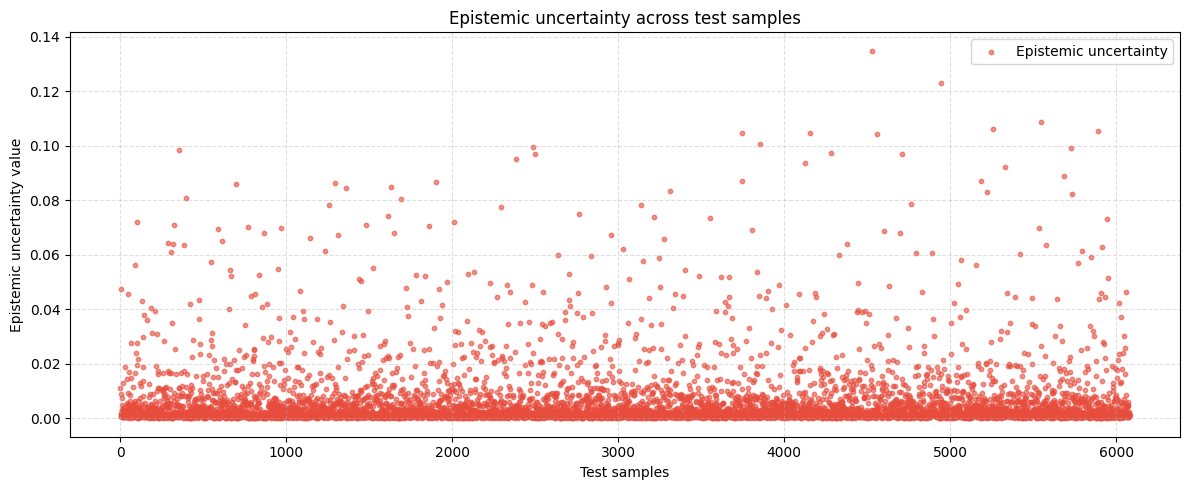

In [140]:
x = np.arange(1, 6081)

plt.figure(figsize=(12, 5))

# Scatter plot for uncertainty
plt.scatter(x, uncertainty, 
            s=10, 
            alpha=0.6, 
            color="#e74c3c",  # attractive red
            label="Epistemic uncertainty")

plt.xlabel("Test samples")
plt.ylabel("Epistemic uncertainty value")
plt.title("Epistemic uncertainty across test samples")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Split the data into two subsets using a 90% uncertainty (k = 0.9).

In [141]:
results1 = []
subset_samples = {}  # <-- store sample indices + values

uncertainty_threshold = 0.1

for target_idx, target_name in enumerate(lbl_itos_deterioration[:2]):

    y_test = y_true[:, target_idx]
    y_pred = all_mean_preds[:, target_idx]
    uncertainty = all_uncertainties[:, target_idx]

    mask = ~np.isnan(y_test)

    # original indices BEFORE filtering
    idx_all = np.arange(len(y_test))[mask]

    y_test = y_test[mask]
    y_pred = y_pred[mask]
    uncertainty = uncertainty[mask]

    for group_name, group_mask in [
        ("uncertainty ≤ 0.1", uncertainty <= uncertainty_threshold),
        ("uncertainty > 0.1", uncertainty > uncertainty_threshold),
    ]:

        idx_group = idx_all[group_mask]

        y_test_group = y_test[group_mask]
        y_pred_group = y_pred[group_mask]
        uncertainty_group = uncertainty[group_mask]

        # store samples for later inspection
        subset_samples[(target_name, group_name)] = {
            "indices": idx_group,
            "y_true": y_test_group,
            "y_pred": y_pred_group,
            "uncertainty": uncertainty_group
        }

        if len(y_test_group) == 0 or len(np.unique(y_test_group)) < 2:
            continue

        auroc = roc_auc_score(y_test_group, y_pred_group)
        auprc = average_precision_score(y_test_group, y_pred_group)
        brier = brier_score_loss(y_test_group, y_pred_group)

        results1.append({
            "target": target_name,
            "group": group_name,
            "auroc": auroc,
            "auprc": auprc,
            "brier_score": brier,
            "mean_uncertainty": uncertainty_group.mean(),
            "test_n": len(y_test_group),
            "positive_rate": y_test_group.mean()
        })
results_df = pd.DataFrame(results1)

#results_df.to_csv(
#    "realmlp_mc_dropout_results_by_uncertainty.csv",
 #   index=False
#)

print("\n===== RESULTS BY UNCERTAINTY =====")
print(results_df.to_string(index=False))


===== RESULTS BY UNCERTAINTY =====
      target             group    auroc    auprc  brier_score  mean_uncertainty  test_n  positive_rate
mortality_1d uncertainty ≤ 0.1 0.923662 0.100997     0.004727          0.005023    6041       0.004966
mortality_1d uncertainty > 0.1 0.622222 0.446218     0.231808          0.138897      28       0.357143
     icu_24h uncertainty ≤ 0.1 0.873544 0.548320     0.061478          0.032423    5691       0.096468
     icu_24h uncertainty > 0.1 0.684836 0.677634     0.227797          0.115618     360       0.502778


In [105]:
certainty_90=subset_samples['icu_24h',
  'uncertainty ≤ 0.1']

uncertainty_90=subset_samples['icu_24h',
  'uncertainty > 0.1']

In [106]:
certainty_90

{'indices': array([   0,    1,    2, ..., 6077, 6078, 6079], shape=(5691,)),
 'y_true': array([0., 1., 0., ..., 0., 0., 0.], shape=(5691,), dtype=float32),
 'y_pred': array([0.24057922, 0.5861666 , 0.0074724 , ..., 0.01993034, 0.01194128,
        0.03064052], shape=(5691,), dtype=float32),
 'uncertainty': array([0.09376689, 0.0952709 , 0.00519829, ..., 0.01103943, 0.00791921,
        0.02097045], shape=(5691,), dtype=float32)}

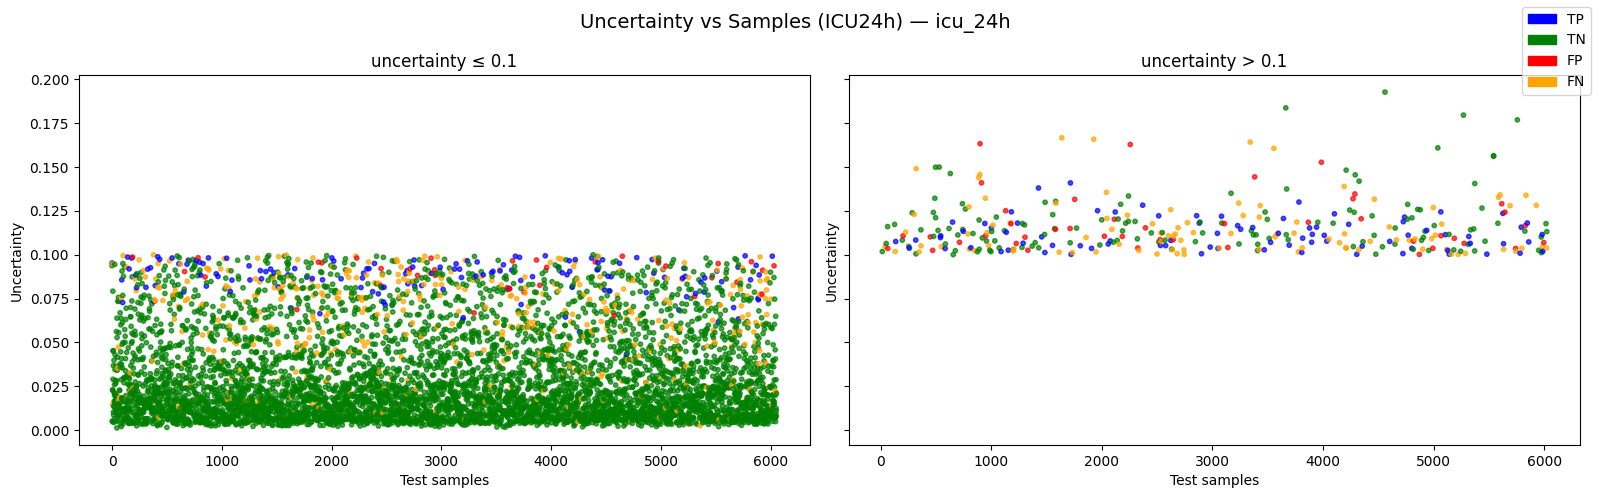

In [87]:


# -----------------------------
# SECOND LABEL ONLY (ICU24h)
# -----------------------------
target_idx = 1
target_name = lbl_itos_deterioration[target_idx]

y_true_l = y_true[:, target_idx]
y_prob_l = all_mean_preds[:, target_idx]
unc_l = all_uncertainties[:, target_idx]

mask = ~np.isnan(y_true_l)

y_true_l = y_true_l[mask]
y_prob_l = y_prob_l[mask]
unc_l = unc_l[mask]

# -----------------------------
# BINARY PREDICTION (needed for TP/FP/FN/TN)
# -----------------------------
y_pred_l = (y_prob_l >= 0.50).astype(int)

# -----------------------------
# CLASSIFY EACH SAMPLE
# -----------------------------
colors = []

for yt, yp in zip(y_true_l, y_pred_l):
    if yt == 1 and yp == 1:
        colors.append("blue")    # TP
    elif yt == 0 and yp == 0:
        colors.append("green")   # TN
    elif yt == 0 and yp == 1:
        colors.append("red")     # FP
    else:
        colors.append("orange")  # FN

colors = np.array(colors)

# -----------------------------
# SPLIT BY UNCERTAINTY
# -----------------------------
low_mask = unc_l <= 0.1
high_mask = unc_l > 0.1

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

groups = [
    ("uncertainty ≤ 0.1", low_mask, axes[0]),
    ("uncertainty > 0.1", high_mask, axes[1])
]

x = np.arange(len(y_true_l))

for title, m, ax in groups:

    ax.scatter(
        x[m],
        unc_l[m],
        c=colors[m],
        s=10,
        alpha=0.7
    )

    ax.set_title(title)
    ax.set_xlabel("Test samples")
    ax.set_ylabel("Uncertainty")

# legend (manual)
import matplotlib.patches as mpatches

legend_items = [
    mpatches.Patch(color="blue", label="TP"),
    mpatches.Patch(color="green", label="TN"),
    mpatches.Patch(color="red", label="FP"),
    mpatches.Patch(color="orange", label="FN"),
]

fig.legend(handles=legend_items, loc="upper right")

fig.suptitle(f"Uncertainty vs Samples (ICU24h) — {target_name}", fontsize=14)

plt.tight_layout()
plt.show()

# Split the data into two subsets using a 95% uncertainty (k = 0.95).

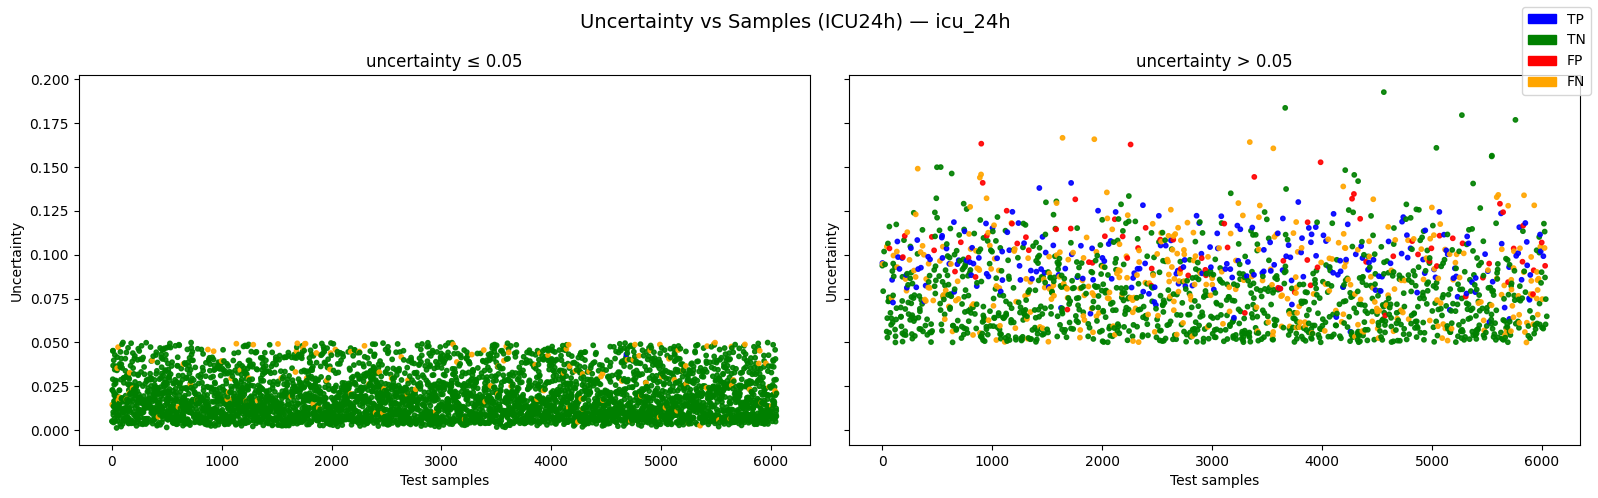

In [89]:


# -----------------------------
# SECOND LABEL ONLY (ICU24h)
# -----------------------------
target_idx = 1
target_name = lbl_itos_deterioration[target_idx]

y_true_l = y_true[:, target_idx]
y_prob_l = all_mean_preds[:, target_idx]
unc_l = all_uncertainties[:, target_idx]

mask = ~np.isnan(y_true_l)

y_true_l = y_true_l[mask]
y_prob_l = y_prob_l[mask]
unc_l = unc_l[mask]

# -----------------------------
# BINARY PREDICTION (needed for TP/FP/FN/TN)
# -----------------------------
y_pred_l = (y_prob_l >= 0.50).astype(int)

# -----------------------------
# CLASSIFY EACH SAMPLE
# -----------------------------
colors = []

for yt, yp in zip(y_true_l, y_pred_l):
    if yt == 1 and yp == 1:
        colors.append("blue")    # TP
    elif yt == 0 and yp == 0:
        colors.append("green")   # TN
    elif yt == 0 and yp == 1:
        colors.append("red")     # FP
    else:
        colors.append("orange")  # FN

colors = np.array(colors)

# -----------------------------
# SPLIT BY UNCERTAINTY
# -----------------------------
low_mask = unc_l <= 0.05
high_mask = unc_l > 0.05

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

groups = [
    ("uncertainty ≤ 0.05", low_mask, axes[0]),
    ("uncertainty > 0.05", high_mask, axes[1])
]

x = np.arange(len(y_true_l))

for title, m, ax in groups:

    ax.scatter(
        x[m],
        unc_l[m],
        c=colors[m],
        s=10,
        alpha=0.9
    )

    ax.set_title(title)
    ax.set_xlabel("Test samples")
    ax.set_ylabel("Uncertainty")

# legend (manual)
import matplotlib.patches as mpatches

legend_items = [
    mpatches.Patch(color="blue", label="TP"),
    mpatches.Patch(color="green", label="TN"),
    mpatches.Patch(color="red", label="FP"),
    mpatches.Patch(color="orange", label="FN"),
]

fig.legend(handles=legend_items, loc="upper right")

fig.suptitle(f"Uncertainty vs Samples (ICU24h) — {target_name}", fontsize=14)

plt.tight_layout()
plt.show()

# Split the data into two subsets using a 97.5% uncertainty (k = 0.975).

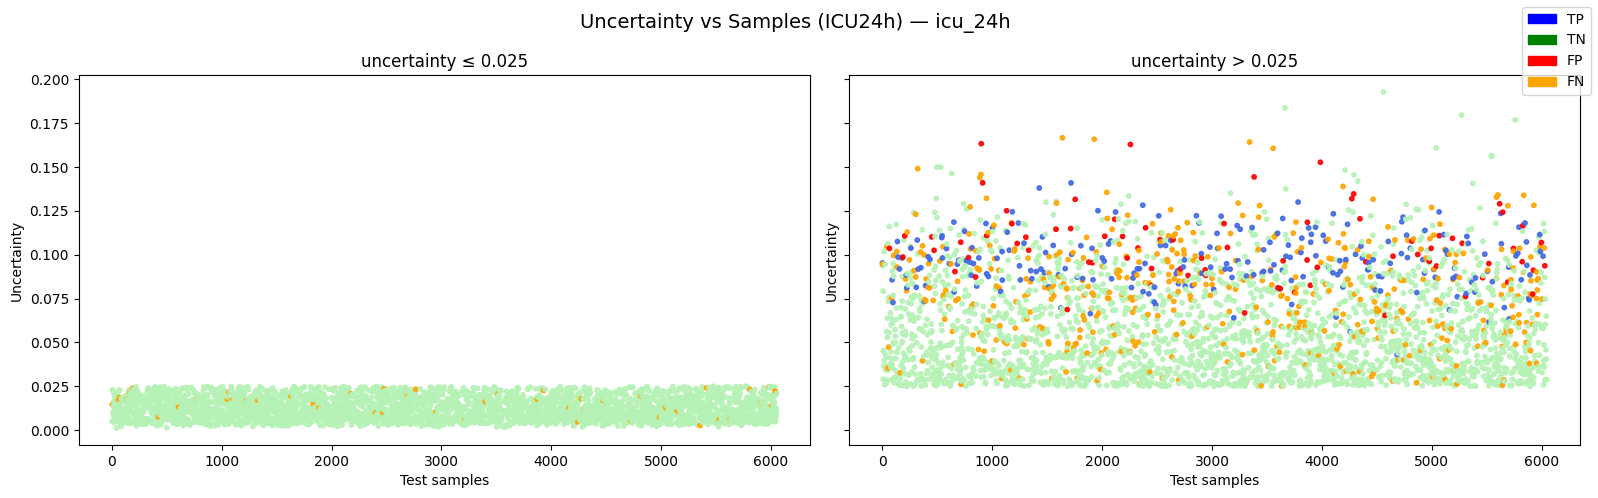

In [101]:


# -----------------------------
# SECOND LABEL ONLY (ICU24h)
# -----------------------------
target_idx = 1
target_name = lbl_itos_deterioration[target_idx]

y_true_l = y_true[:, target_idx]
y_prob_l = all_mean_preds[:, target_idx]
unc_l = all_uncertainties[:, target_idx]

mask = ~np.isnan(y_true_l)

y_true_l = y_true_l[mask]
y_prob_l = y_prob_l[mask]
unc_l = unc_l[mask]

# -----------------------------
# BINARY PREDICTION (needed for TP/FP/FN/TN)
# -----------------------------
y_pred_l = (y_prob_l >= 0.50).astype(int)

# -----------------------------
# CLASSIFY EACH SAMPLE
# -----------------------------
colors = []

for yt, yp in zip(y_true_l, y_pred_l):
    if yt == 1 and yp == 1:
        colors.append("royalblue")   # TP
    elif yt == 0 and yp == 0:
        colors.append("#b6f2b6")   # TN
    elif yt == 0 and yp == 1:
        colors.append("red")     # FP
    else:
        colors.append("orange")  # FN

colors = np.array(colors)

# -----------------------------
# SPLIT BY UNCERTAINTY
# -----------------------------
low_mask = unc_l <= 0.025
high_mask = unc_l > 0.025

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

groups = [
    ("uncertainty ≤ 0.025", low_mask, axes[0]),
    ("uncertainty > 0.025", high_mask, axes[1])
]

x = np.arange(len(y_true_l))

for title, m, ax in groups:

    ax.scatter(
        x[m],
        unc_l[m],
        c=colors[m],
        s=10,
        alpha=0.9
    )

    ax.set_title(title)
    ax.set_xlabel("Test samples")
    ax.set_ylabel("Uncertainty")

# legend (manual)
import matplotlib.patches as mpatches

legend_items = [
    mpatches.Patch(color="blue", label="TP"),
    mpatches.Patch(color="green", label="TN"),
    mpatches.Patch(color="red", label="FP"),
    mpatches.Patch(color="orange", label="FN"),
]

fig.legend(handles=legend_items, loc="upper right")

fig.suptitle(f"Uncertainty vs Samples (ICU24h) — {target_name}", fontsize=14)

plt.tight_layout()
plt.show()

In [99]:

classes = np.array(colors)

# -----------------------------
# SPLIT MASKS
# -----------------------------
low_mask = unc_l <= 0.05
high_mask = unc_l > 0.05

# -----------------------------
# COUNT FUNCTION
# -----------------------------
def count_metrics(mask):
    return {
        "TP": np.sum((classes == "blue") & mask),
        "TN": np.sum((classes == "green") & mask),
        "FP": np.sum((classes == "red") & mask),
        "FN": np.sum((classes == "orange") & mask),
    }

# -----------------------------
# CREATE TABLE
# -----------------------------
table = pd.DataFrame([
    count_metrics(low_mask),
    count_metrics(high_mask)
], index=[
    "uncertainty ≤ 0.05",
    "uncertainty > 0.05"
])

print(table)

                     TP    TN  FP   FN
uncertainty ≤ 0.05    1  4169   0  135
uncertainty > 0.05  222  1073  79  372


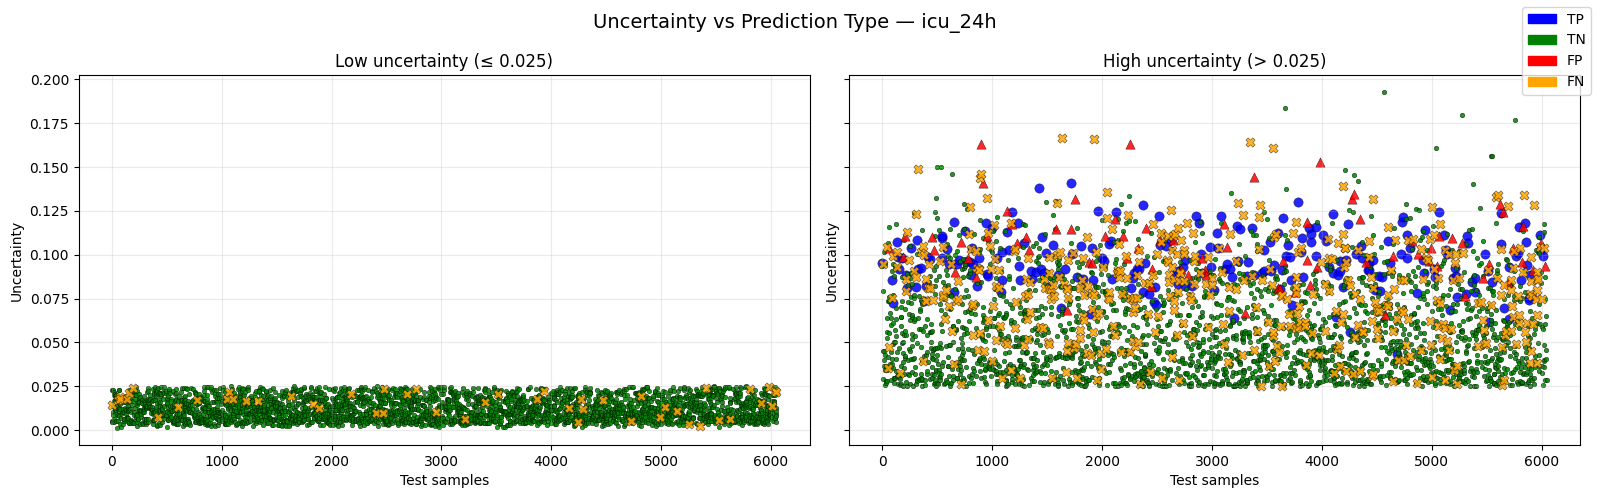

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

class_map = {
    "TP": ("blue", "o"),
    "TN": ("green", "."),
    "FP": ("red", "^"),
    "FN": ("orange", "X")
}

x = np.arange(len(y_true_l))

groups = [
    ("Low uncertainty (≤ 0.025)", low_mask, axes[0]),
    ("High uncertainty (> 0.025)", high_mask, axes[1])
]

for title, mask_group, ax in groups:

    for cls, (color, marker) in class_map.items():

        mask = (classes == cls) & mask_group

        ax.scatter(
            x[mask],
            unc_l[mask],
            c=color,
            marker=marker,
            s=45,              # bigger points = easier to see
            alpha=0.85,        # less fading for clarity
            edgecolors="black",
            linewidths=0.3
        )

    ax.set_title(title)
    ax.set_xlabel("Test samples")
    ax.set_ylabel("Uncertainty")
    ax.grid(alpha=0.25)

# clean legend
import matplotlib.patches as mpatches

legend_items = [
    mpatches.Patch(color="blue", label="TP"),
    mpatches.Patch(color="green", label="TN"),
    mpatches.Patch(color="red", label="FP"),
    mpatches.Patch(color="orange", label="FN"),
]

fig.legend(handles=legend_items, loc="upper right")

fig.suptitle(f"Uncertainty vs Prediction Type — {target_name}", fontsize=14)

plt.tight_layout()
plt.show()

# Threshold per uncertainty bucket

In [124]:
# ----------------------------------------
# align lengths upfront
# ----------------------------------------
min_len = min(len(y_test), len(pred_prob), len(uncertainty))

y_test_v      = y_test[:min_len]
pred_prob_v   = pred_prob[:min_len]
uncertainty_v = uncertainty[:min_len]

valid_mask    = ~np.isnan(y_test_v)

y_test_v      = y_test_v[valid_mask]
pred_prob_v   = pred_prob_v[valid_mask]
uncertainty_v = uncertainty_v[valid_mask]

# ----------------------------------------
# percentile thresholds
# ----------------------------------------
u_75 = np.percentile(uncertainty_v, 75)
u_90 = np.percentile(uncertainty_v, 90)
u_95 = np.percentile(uncertainty_v, 95)

# ----------------------------------------
# BEFORE: fixed threshold
# ----------------------------------------
y_pred_fixed = (pred_prob_v >= 0.1238).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test_v, y_pred_fixed).ravel()

n          = len(y_test_v)
n_pos      = tp + fn
n_neg      = tn + fp
n_pred_pos = tp + fp

print("=" * 50)
print("BEFORE — fixed threshold (0.1238)")
print("=" * 50)
print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")
print(f"  prevalence%       (pos/n)       : {100 * n_pos / n:.1f}%")
print(f"  sensitivity%      (TP/pos)      : {100 * tp / n_pos:.1f}%")
print(f"  precision%        (TP/(TP+FP))  : {100 * tp / n_pred_pos:.1f}%")
print(f"  FDR%              (FP/(TP+FP))  : {100 * fp / n_pred_pos:.1f}%")
print(f"  FN/(FN+TN)%                     : {100 * fn / (fn + tn):.1f}%")
print(f"  fall-out%         (FP/neg)      : {100 * fp / n_neg:.1f}%")
print(f"  specificity%      (TN/neg)      : {100 * tn / n_neg:.1f}%")

# ----------------------------------------
# AFTER: adaptive threshold
# ----------------------------------------
threshold = np.where(uncertainty_v > u_75, 0.01, 0.1238)#                                       ↑ lower → fires more → catches more FN
y_pred_adapt = (pred_prob_v > threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test_v, y_pred_adapt).ravel()

n_pos      = tp + fn
n_neg      = tn + fp
n_pred_pos = tp + fp

print()
print("=" * 50)
print("AFTER — adaptive threshold (0.1238 / 0.48 at u_75)")
print("=" * 50)
print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")
print(f"  prevalence%       (pos/n)       : {100 * n_pos / n:.1f}%")
print(f"  sensitivity%      (TP/pos)      : {100 * tp / n_pos:.1f}%")
print(f"  precision%        (TP/(TP+FP))  : {100 * tp / n_pred_pos:.1f}%")
print(f"  FDR%              (FP/(TP+FP))  : {100 * fp / n_pred_pos:.1f}%")
print(f"  FN/(FN+TN)%                     : {100 * fn / (fn + tn):.1f}%")
print(f"  fall-out%         (FP/neg)      : {100 * fp / n_neg:.1f}%")
print(f"  specificity%      (TN/neg)      : {100 * tn / n_neg:.1f}%")

BEFORE — fixed threshold (0.1238)
  TP=601  FP=1120  TN=4201  FN=129
  prevalence%       (pos/n)       : 12.1%
  sensitivity%      (TP/pos)      : 82.3%
  precision%        (TP/(TP+FP))  : 34.9%
  FDR%              (FP/(TP+FP))  : 65.1%
  FN/(FN+TN)%                     : 3.0%
  fall-out%         (FP/neg)      : 21.0%
  specificity%      (TN/neg)      : 79.0%

AFTER — adaptive threshold (0.1238 / 0.48 at u_75)
  TP=609  FP=1191  TN=4130  FN=121
  prevalence%       (pos/n)       : 12.1%
  sensitivity%      (TP/pos)      : 83.4%
  precision%        (TP/(TP+FP))  : 33.8%
  FDR%              (FP/(TP+FP))  : 66.2%
  FN/(FN+TN)%                     : 2.8%
  fall-out%         (FP/neg)      : 22.4%
  specificity%      (TN/neg)      : 77.6%


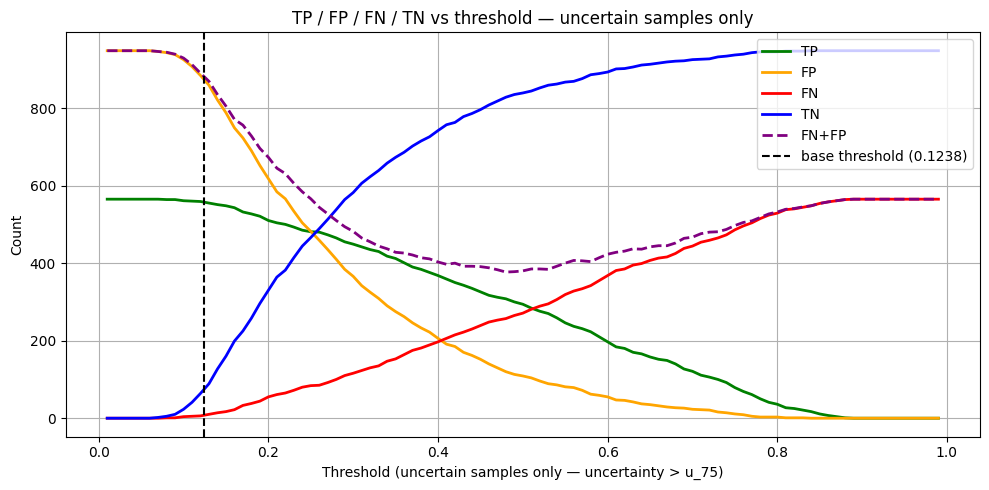

In [126]:
uncertain_mask = uncertainty_v > u_75

y_test_u      = y_test_v[uncertain_mask]
pred_prob_u   = pred_prob_v[uncertain_mask]
uncertainty_u = uncertainty_v[uncertain_mask]
# ----------------------------------------
# SWEEP: uncertain samples only
# ----------------------------------------
sweep_values = np.arange(0.01, 1.00, 0.01)

tps, fps, fns, tns = [], [], [], []

for t in sweep_values:
    y_pred = (pred_prob_u >= t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test_u, y_pred).ravel()
    tps.append(tp_)
    fps.append(fp_)
    fns.append(fn_)
    tns.append(tn_)

# ----------------------------------------
# PLOT
# ----------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sweep_values, tps,                            label="TP",    color="green",  linewidth=2)
ax.plot(sweep_values, fps,                            label="FP",    color="orange", linewidth=2)
ax.plot(sweep_values, fns,                            label="FN",    color="red",    linewidth=2)
ax.plot(sweep_values, tns,                            label="TN",    color="blue",   linewidth=2)
ax.plot(sweep_values, np.array(fns) + np.array(fps),  label="FN+FP", color="purple", linewidth=2, linestyle="--")

ax.axvline(0.1238, color="black", linestyle="--", linewidth=1.5, label="base threshold (0.1238)")

ax.set_xlabel("Threshold (uncertain samples only — uncertainty > u_75)")
ax.set_ylabel("Count")
ax.set_title("TP / FP / FN / TN vs threshold — uncertain samples only")
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()